# Transportgleichung 1d [Matlab]

Hier wird eine mögliche Implementierung der eindimensionalen Transportgleichung besprochen. Die zugehörige Quelldatei [`Transportgleichung_1d.m`](Transportgleichung_1d.m) befindet sich ebenfalls im Begleitmaterial. Dabei wird die Gleichung wie folgt modelliert:

$$
    \partial_t \Phi = c\partial_x^2\Phi - u\partial_x\Phi + r\Phi,
$$

wobei _`c`_ die Diffusionskonstante, _`u`_ die Transportgeschwindigkeit und _`r`_ eine zur Konzentration der Strömungsgröße _`Φ`_ proportionale Quelle beschreibt. Es handelt sich somit um eine partielle Differentialgleichung von 1. Ordnung in der Zeit _`t`_ und 2. Ordnung im Ort _`x`_. Unabhängig von den gewählten Diskretisierungsverfahren ist die Vorgehensweise immer dieselbe.

1. _Örtliche Auflösung_ der partiellen Differentialgleichung unter gewissen _Randbedingungen_
2. _Zeitliche Auflösung_ der so entstandenen gewöhnlichen Differentialgleichung unter gewissen _Anfangsbedingungen_

_**Tipp:** Außerdem sei noch erwähnt, dass es zu einem guten Programmierstil gehört, das Hauptprogramm weitestgehend in Subfunktionen zu unterteilen, um die Übersichtlichkeit des Quellcodes zu steigern. Ein sog. Docstring kann dabei helfen, die einzelnen Funktionen schneller zu verstehen. Man tut auch selbst gut dabei, den Quellcode ausreichend (aber nicht übermäßig) mit Kommentaren zu versehen, damit er für spätere Zwecke gut dokumentiert ist. So macht man sich das eigene Leben und das von anderen Mitentwicklerinnen und Mitentwicklern sehr viel leichter._

## Subfunktion: Raumdiskretisierung

Zunächst wird die Transportgleichung im Raum diskretisiert. Dafür wird die Anzahl an Stützstellen entlang einer Gesamtlänge festgelegt, um ein äquidistantes Gitter und ein symmetrisches Spektrum an diskreten Wellenzahlen zu generieren. Diese Wellenzahlen werden dafür benötigt, die Ortsableitungen per Fourier-Transformation zu berechnen. Diese sog. Spektral-Methode stellt eine Alternative zur herkömmlichen Finite-Differenzen-Methode dar, kann jedoch nur bei äquidistanten Gittern und periodischen Randbedingungen verwendet werden. Symmetrisch ist das Spektrum an Wellenzahlen deshalb, weil dies den Algorithmus für die sog. schnelle Fourier-Transformation (FFT) effizient gestaltet. Die entscheidene Eigenschaft der Fourier-Transformation, welche man sich bei der Spektral-Methode zunutze macht, ist, die Abbildung von Ableitungen in Form einer Multiplikation im Bildbereich:

$$
    \mathcal{F}[\partial_x^k \Phi] = (\mathrm{i}\lambda)^k \mathcal{F}[\Phi],
$$

wobei `i` die imaginäre Einheit und _`λ`_ die entsprechende Wellenzahl bezeichnet. Bei zeitlicher Ableitung wäre letztere jedoch eine Frequenz.

In [1]:
function [x,lbda] = Raumdiskretisierung()
% Rückgabe
% --------
% x:    äquidistantes 1d-Gitter
% lbda: diskrete Wellenzahlen

N    = 256; % Anzahl der Stützstellen
L    = 30;  % Gesamtlänge

x    = linspace(0,L,N)';
lbda = (2*pi/L)*(-N/2:N/2-1);
lbda = fftshift(lbda)'; % für die FFT benötigte Anordnung
end

## Subfunktion: Startverteilung

Für die zeitliche Auflösung der Transportgleichung wird eine Startverteilung der Strömungsgröße _`Φ`_ als Anfangsbedingung angesetzt. Diese Startverteilung wird hier als Hut-Funktion gewählt.

In [2]:
function phi0 = Startverteilung(x)
% Rückgabe
% --------
% phi0: Startverteilung der Strömungsgröße als Hut-Funktion

N = length(x); % Anzahl der Stützstellen
a = 1;         % linke Position
b = 2;         % rechte Position
s = 0.8;       % Skalierungsfaktor
phimax = 0.1;  % Maximalwert

% linke Seite
phi1 = (x-a*ones(N,1)+s*ones(N,1)).^3.*(a*ones(N,1)-x+s*ones(N,1)).^3;
phi1(x<a-s|x>a+s) = 0;

% rechte Seite
phi2 = (x-b*ones(N,1)+s*ones(N,1)).^3.*(b*ones(N,1)-x+s*ones(N,1)).^3;
phi2(x<b-s|x>b+s) = 0;

% Superposition und Normierung
phi0 = (phi1+phi2)/max(phi1+phi2)*phimax;
end

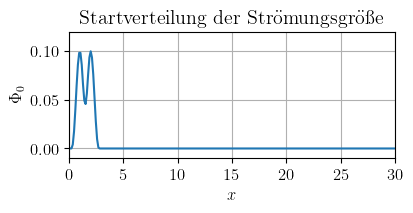

In [3]:
[x,~] = Raumdiskretisierung();
phi0  = Startverteilung(x);

% Plot der Startverteilung
plot(x,phi0);
ylim([-0.01 .12]);
ylabel('$\Phi_0$','Interpreter','latex');
xlabel('$x$','Interpreter','latex');
title('Startverteilung der Strömungsgröße');
set(gcf,'color','w');
grid on;

## Subfunktion: Zeitfunktion

Wird die Spektral-Methode auf die Transportgleichung angewendet, dann schreibt sie sich wie folgt:

$$
    \partial_t \Phi = \mathcal{F}^{-1}[(c(\mathrm{i}\lambda)^2 - u(\mathrm{i}\lambda))\mathcal{F}[\Phi]] + r\Phi
$$

Die so entstehenden Zahlen sind nach der Fourier-Transformation komplex, der Imaginäranteil wird jedoch nach der Rücktransformation nicht mehr benötigt. Um die Strömungsgröße _`Φ`_ zu berechnen, kann nun ein Zeitschrittverfahren zur Integration verwendet werden.

In [4]:
function phi_dot = Zeitfunktion(phi,u,c,r,lbda)
% Rückgabe
% --------
% phi_dot: Zeitableitung der Strömungsgröße

phi_dot = real(ifft((c*(1i*lbda).^2-u*(1i*lbda)).*fft(phi))) + r*phi;
end

## Subfunktion: Plot

Die Darstellung des zeitlichen Verlaufs wird auch in eine separate Funktion ausgelagert. Diese Funktion ermöglicht es außerdem, die erstellte Animation als GIF-Datei zu exportieren.

In [5]:
function Plot(u,c,r,T,x,t,phi,options)
arguments
    u double         % Transportgeschwindigkeit
    c double         % Diffusionskonstante
    r double         % Quelle (proportional zur Konzentration)
    T double         % Simulationsendzeit
    x (:,1) double   % äquidistantes 1d-Gitter
    t (1,:) double   % Zeitwerte
    phi (:,:) double % Funktionswerte
    options.gif_export logical = false % optionaler gif Export
end

% Ploteinstellungen
line = plot(nan,nan);
line.XData = x;
ylim([-0.01 .12]);
ylabel('$\Phi$','Interpreter','latex');
xlabel('$x$','Interpreter','latex');
set(gcf,'color','w');
grid on;

% Darstellung von 100 Zeitschritten
for i = 1:round(length(t)/100):length(t)
    line.YData = phi(i,:);
    title([
        '$u=' num2str(u) '$, ' ...
        '$c=' num2str(c) '$, ' ...
        '$r=' num2str(r) '$, ' ...
        '$t=' num2str(t(i),'%.2f') '$' ...
    ],'Interpreter','latex');
    
    % optionaler gif Export
    if options.gif_export
        file = ['u' num2str(u) ...
            '_c' num2str(c) ...
            '_r' num2str(r) ...
            '_T' num2str(T) '.gif'];
        if i==1
            exportgraphics(gcf,file);
        else
            exportgraphics(gcf,file,'Append',true);
        end
    else
        drawnow;
        pause(.05);
    end
end
end

## Hauptprogramm: Transportgleichung_1d

In dem Hauptprogramm werden letztendlich alle Subfunktionen zusammengeführt.

In [6]:
function Transportgleichung_1d(u,c,r,T,options)
arguments
    u double % Transportgeschwindigkeit
    c double % Diffusionskonstante
    r double % Quelle (proportional zur Konzentration)
    T double % Simulationsendzeit
    options.gif_export logical = false % optionaler gif Export
end

% Diskretisierung des eindimensionalen Rechenraumes
[x,lbda] = Raumdiskretisierung();

% Startverteilung
phi0 = Startverteilung(x);

% Definition der in der Zeit zu integrierenden Funktion
% -> Zeitfunktion(phi,u,c,r,lbda)

% Lösung mit Zeitschrittverfahren
[t,phi] = ode45(@(t,phi) Zeitfunktion(phi,u,c,r,lbda),[0,T],phi0);

% Plot der zeitlichen Entwicklung
Plot(u,c,r,T,x,t,phi,gif_export=options.gif_export);
end

In [7]:
% Beispiel Simulation
Transportgleichung_1d(60,1,1,.5);